In [511]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [512]:
df = pd.read_csv('titanic_openml.csv') #openml не работает, не могу скачать датасет с помощью команд. скачал его с сайта.

In [513]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   float64
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   float64
 6   parch      1309 non-null   float64
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(6), int64(1), object(7)
memory usage: 143.3+ KB


In [514]:
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1.0,1,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [515]:
df = df.drop(['boat','body'], axis=1) #утечка данных (номер спасательной шлюпки - есть только у живых, номер тела - только у погибших)
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest
0,1.0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,"St Louis, MO"
1,1.0,1,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON"
2,1.0,0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON"
3,1.0,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON"
4,1.0,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,"Montreal, PQ / Chesterville, ON"


In [516]:
df.isnull().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
home.dest     564
dtype: int64

In [517]:
df = df.drop('cabin', axis=1) #много пропусков
df = df.drop('home.dest', axis=1) #высококардинальный, титаник не доплыл
df = df.drop('ticket',axis=1) #высококардинальный

In [518]:
df['pclass'] = pd.to_numeric(df['pclass'], downcast='integer') #преобразуем в целочисленные значения
df['sibsp'] = pd.to_numeric(df['sibsp'], downcast='integer')
df['parch'] = pd.to_numeric(df['parch'], downcast='integer')

In [519]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int8   
 1   survived  1309 non-null   int64  
 2   name      1309 non-null   object 
 3   sex       1309 non-null   object 
 4   age       1046 non-null   float64
 5   sibsp     1309 non-null   int8   
 6   parch     1309 non-null   int8   
 7   fare      1308 non-null   float64
 8   embarked  1307 non-null   object 
dtypes: float64(2), int64(1), int8(3), object(3)
memory usage: 65.3+ KB


<Axes: xlabel='pclass', ylabel='survived'>

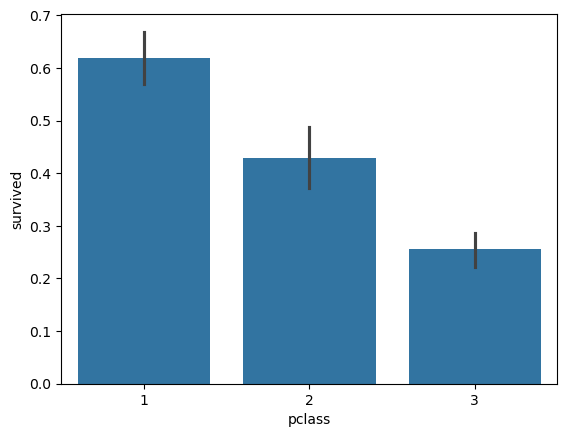

In [520]:
sns.barplot(x='pclass',y='survived',data=df) #чем выше класс билета - тем больше людей выжило

In [521]:
df['sex'].value_counts()

sex
male      843
female    466
Name: count, dtype: int64

<Axes: xlabel='sex', ylabel='survived'>

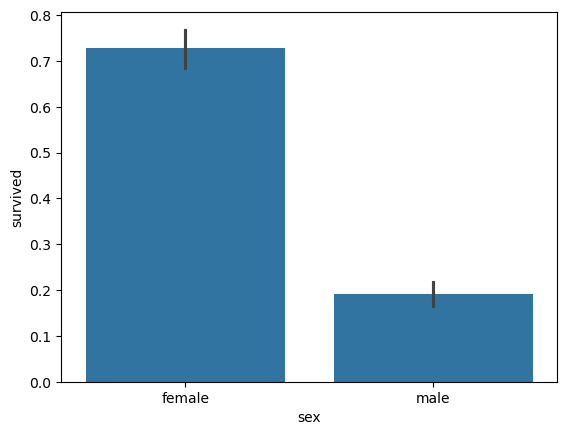

In [522]:
sns.barplot(x='sex',y='survived',data=df) #у женщин больше шанс спастись

<Axes: xlabel='pclass', ylabel='survived'>

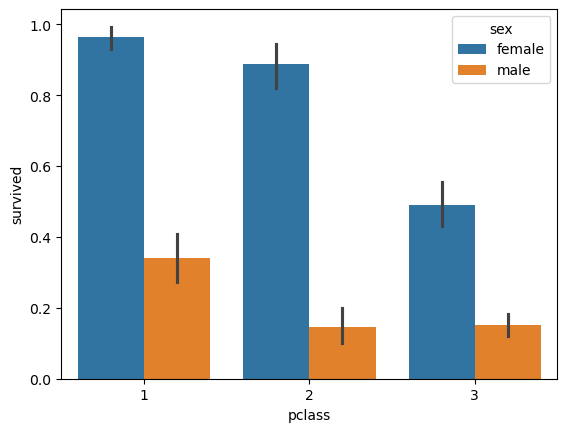

In [523]:
sns.barplot(x='pclass',y='survived',data=df,hue='sex') #женщины с билетами 1 и 2 класса имеют около 90% шансов на спасение
                                                       #мужчины 2 и 3 класса имеют всего 10% шансов на спасение

<Axes: xlabel='embarked', ylabel='survived'>

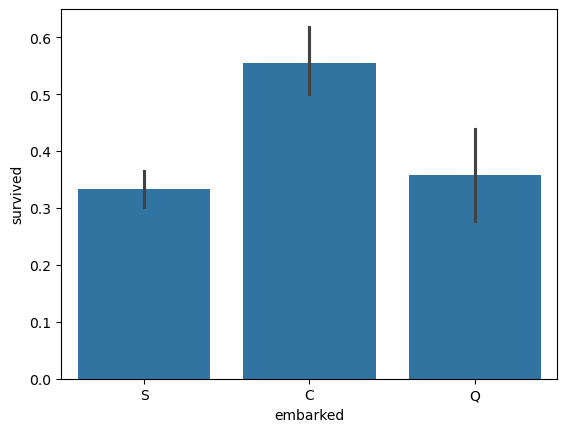

In [524]:
sns.barplot(x='embarked',y='survived',data=df) #люди, севшие в порту C, выживают с больше вероятностью, чем люди севшие в S или Q

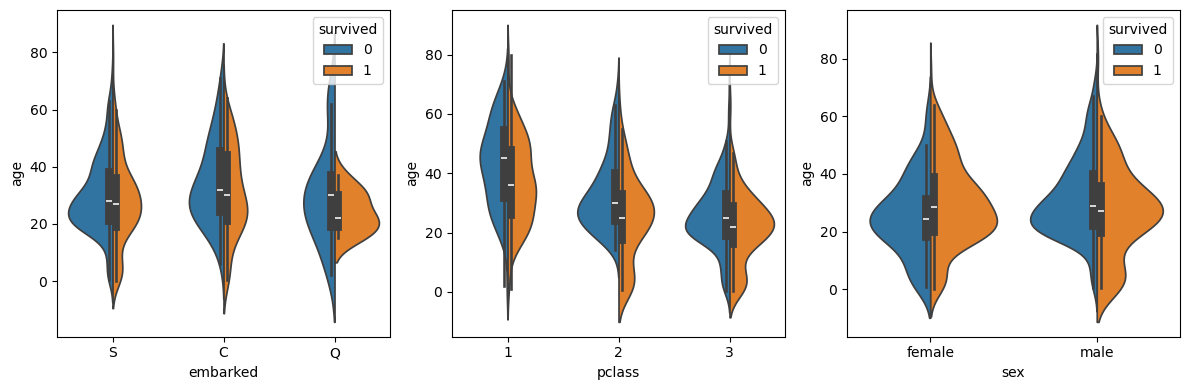

In [525]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

sns.violinplot(x="embarked", y="age", hue="survived", 
               data=df, split=True, ax=ax1)
sns.violinplot(x="pclass", y="age", hue="survived", 
               data=df, split=True, ax=ax2)
sns.violinplot(x="sex", y="age", hue="survived", 
               data=df, split=True, ax=ax3)

plt.tight_layout()
plt.show()

<Axes: >

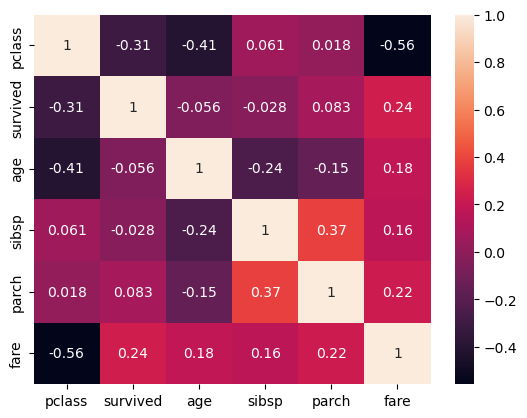

In [526]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [527]:
df['title'] = df['name'].str.extract(r',\s*([^\.]+)\.') #извлекаем титул человека из имени
df['title'].value_counts()

title
Mr              757
Miss            260
Mrs             197
Master           61
Dr                8
Rev               8
Col               4
Major             2
Mlle              2
Ms                2
Lady              1
Capt              1
Mme               1
Sir               1
Jonkheer          1
Dona              1
Don               1
the Countess      1
Name: count, dtype: int64

In [528]:
mapping = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs",
    "Sir": "Mr",
    "Don": "Mr",
    "Jonkheer": "Mr",
    "the Countess": "Mrs",
    "Lady": "Mrs",
    "Dona": "Mrs",
    "Dr": "Officer",
    "Rev": "Officer",
    "Col": "Officer",
    "Major": "Officer",
    "Capt": "Officer"
}

df['title'] = df['title'].replace(mapping) #объединяем маленькие группы
df['title'].value_counts()

title
Mr         760
Miss       264
Mrs        201
Master      61
Officer     23
Name: count, dtype: int64

In [529]:
df['family_size'] = df['parch'] + df['sibsp'] + 1 #создал более удобный признак (размер семьи)
df['is_alone'] = (df['family_size'] == 1).astype(int) #создал бинарный признак (1 человек путешествовал или нет)
df['sex'] = df['sex'].map({'male': 1, 'female': 0}) #привожу колонку к бинарному виду

df = df.drop(['parch','sibsp'],axis=1)

In [530]:
from sklearn.model_selection import train_test_split

X = df.drop(['survived','name'],axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

age_by_title = X_train.groupby('title')['age'].median() #медианные возраста по статусам
for dataset in [X_train, X_test]:
    mask = dataset['age'].isna()
    dataset.loc[mask, 'age'] = dataset.loc[mask, 'title'].map(age_by_title) #заменяю пустые возраста на медианные по титулу

fare_median = X_train.groupby(['pclass', 'embarked'])['fare'].median() #медианные стоимости билеты в зависимости от порта и класса билета
for dataset in [X_train, X_test]:
    mask = dataset['fare'].isna()
    dataset.loc[mask, 'fare'] = dataset.loc[mask, ['pclass', 'embarked']].apply(lambda r: fare_median.get((r['pclass'], r['embarked'])), axis=1) #заменяю пустые значения

embarked_mode = X_train['embarked'].mode()[0] #самый популярный порт
X_train['embarked'] = X_train['embarked'].fillna(embarked_mode) #заменяем пустые значения
X_test['embarked'] = X_test['embarked'].fillna(embarked_mode)


#все рассчёты медиан и моды происходят на тренировочных данных, чтобы не было утечки данных

In [531]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['embarked', 'title']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe.fit(X_train[categorical_cols])

X_train_ohe = pd.DataFrame(ohe.transform(X_train[categorical_cols]), columns=ohe.get_feature_names_out(categorical_cols), index=X_train.index)
X_test_ohe = pd.DataFrame(ohe.transform(X_test[categorical_cols]), columns=ohe.get_feature_names_out(categorical_cols), index=X_test.index)

X_train = X_train.drop(categorical_cols, axis=1).join(X_train_ohe)
X_test = X_test.drop(categorical_cols, axis=1).join(X_test_ohe)

#выполняю OHE

In [532]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [150, 300, 500],
    'max_depth': [3, 5, 7, 10], 
    'min_samples_leaf': [4, 6, 8, 12], 
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"best accuracy: {grid_search.best_score_:.4f}")
print(grid_search.best_params_)

#подбираю лучшие параметры с помощью сетки

Fitting 5 folds for each of 96 candidates, totalling 480 fits
best accuracy: 0.8185
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 8, 'n_estimators': 500}


In [533]:
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(criterion='gini', max_depth = 5, min_samples_leaf = 8, n_estimators = 500, random_state=42)
rf.fit(X_train,y_train)
result = rf.predict(X_test)
print(f"Accuracy on test: {accuracy_score(y_test,result):.4f}")

Accuracy on test: 0.7863


In [534]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances

sex              0.257383
title_Mr         0.225445
pclass           0.112261
title_Mrs        0.088199
fare             0.086816
title_Miss       0.067156
family_size      0.055133
age              0.050620
embarked_C       0.018627
is_alone         0.012296
embarked_S       0.010361
title_Master     0.009016
title_Officer    0.003642
embarked_Q       0.003047
dtype: float64

In [ ]:
#sex и title_Mr вместе дают 0.43. По факту они частично дублируют друг друга - title_Mr уже несёт информацию о поле
#можно попробовать убрать sex и посмотреть результат (титулы более информативны т.к. дополнительно кодируют возраст,пол и статус)
X_train = X_train.drop('sex',axis=1)
X_test = X_test.drop('sex',axis=1)

In [536]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [150, 300, 500],
    'max_depth': [3, 5, 7, 10], 
    'min_samples_leaf': [4, 6, 8, 12], 
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"best accuracy: {grid_search.best_score_:.4f}")
print(grid_search.best_params_)

#подбираю лучшие параметры с помощью сетки

Fitting 5 folds for each of 96 candidates, totalling 480 fits
best accuracy: 0.8214
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 150}


In [539]:
rf = RandomForestClassifier(criterion='gini', max_depth = 5, min_samples_leaf = 4, n_estimators = 150, random_state=42)
rf.fit(X_train,y_train)
result = rf.predict(X_test)
print(f"Accuracy on test: {accuracy_score(y_test,result):.4f}")
#accuracy не изменилась - значит title полностью покрывает эту информацию

Accuracy on test: 0.7863


In [538]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances

title_Mr         0.313940
title_Miss       0.125859
title_Mrs        0.120230
pclass           0.119078
fare             0.114455
family_size      0.068907
age              0.055873
is_alone         0.026296
embarked_C       0.021624
title_Officer    0.010666
embarked_S       0.009926
title_Master     0.009289
embarked_Q       0.003855
dtype: float64

In [ ]:
#попробую удалить is_alone, т.к. is_alone и family_size дублируют друг друга частично
X_train = X_train.drop('is_alone',axis=1)
X_test = X_test.drop('is_alone',axis=1)

In [541]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [150, 300, 500],
    'max_depth': [3, 5, 7, 10], 
    'min_samples_leaf': [4, 6, 8, 12], 
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"best accuracy: {grid_search.best_score_:.4f}")
print(grid_search.best_params_)

#подбираю лучшие параметры с помощью сетки

Fitting 5 folds for each of 96 candidates, totalling 480 fits
best accuracy: 0.8242
{'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 6, 'n_estimators': 500}


In [543]:
rf = RandomForestClassifier(criterion='gini', max_depth = 7, min_samples_leaf = 6, n_estimators = 500, random_state=42)
rf.fit(X_train,y_train)
result = rf.predict(X_test)
print(f"Accuracy on test: {accuracy_score(y_test,result):.4f}")
#accuracy упала - значит is_alone стоит оставить

Accuracy on test: 0.7710


In [544]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances

title_Mr         0.304789
fare             0.136207
title_Mrs        0.126547
pclass           0.113316
title_Miss       0.106633
family_size      0.078964
age              0.076903
embarked_C       0.018863
embarked_S       0.014818
title_Officer    0.011984
title_Master     0.006804
embarked_Q       0.004173
dtype: float64